# Experiment 7

### Evaluate the Trained Model's Performance Metrics (Accuracy, Loss) on a Separate Validation Set

In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [2]:
(X, y), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X.shape)
print("Test Data Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Test Data Shape: (10000, 28, 28)


In [3]:
X = X / 255.0
X_test = X_test / 255.0

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)

Train Shape: (48000, 28, 28)
Validation Shape: (12000, 28, 28)


In [5]:
model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(
    optimizer=Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9223 - loss: 0.2637 - val_accuracy: 0.9600 - val_loss: 0.1345
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9664 - loss: 0.1092 - val_accuracy: 0.9680 - val_loss: 0.1081
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9769 - loss: 0.0763 - val_accuracy: 0.9691 - val_loss: 0.1041
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9815 - loss: 0.0572 - val_accuracy: 0.9740 - val_loss: 0.0907
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9859 - loss: 0.0446 - val_accuracy: 0.9744 - val_loss: 0.0905
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9881 - loss: 0.0372 - val_accuracy: 0.9695 - val_loss: 0.1133
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9902 - loss: 0.0290 - val_accuracy: 0.9726 - val_loss: 0.0986
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9916 - loss: 0.0258 -

In [8]:
val_loss, val_acc = model.evaluate(X_val, y_val)

print("Validation Loss:", round(val_loss,4))
print("Validation Accuracy:", round(val_acc*100,2), "%")

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9764 - loss: 0.1049
Validation Loss: 0.1049
Validation Accuracy: 97.64 %


In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", round(test_loss,4))
print("Test Accuracy:", round(test_acc*100,2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.1079
Test Loss: 0.1079
Test Accuracy: 97.58 %


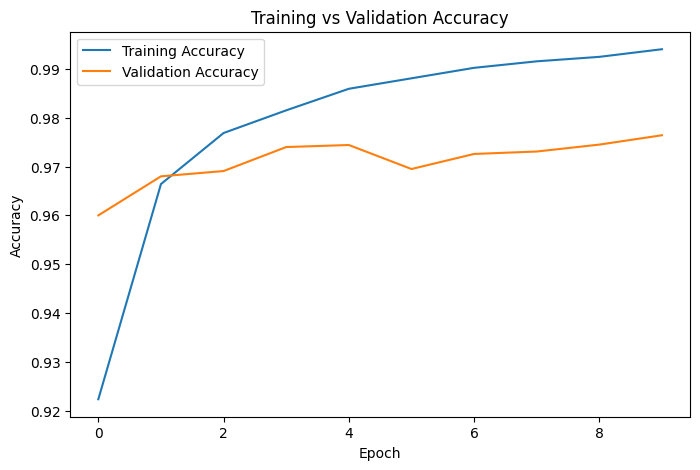

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

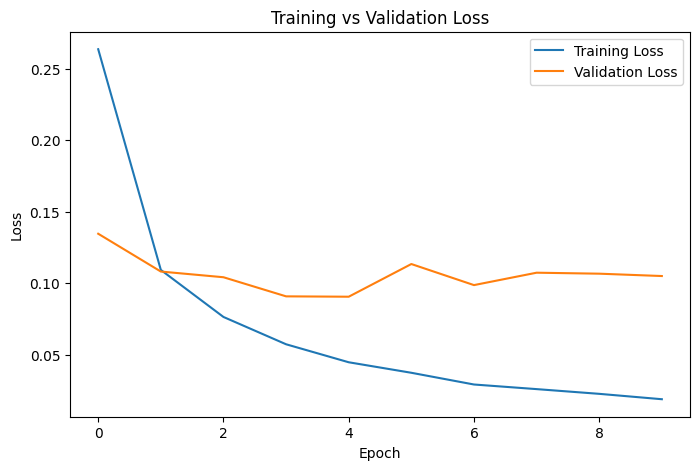

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
pred_probs = model.predict(X_val)
pred_classes = np.argmax(pred_probs, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


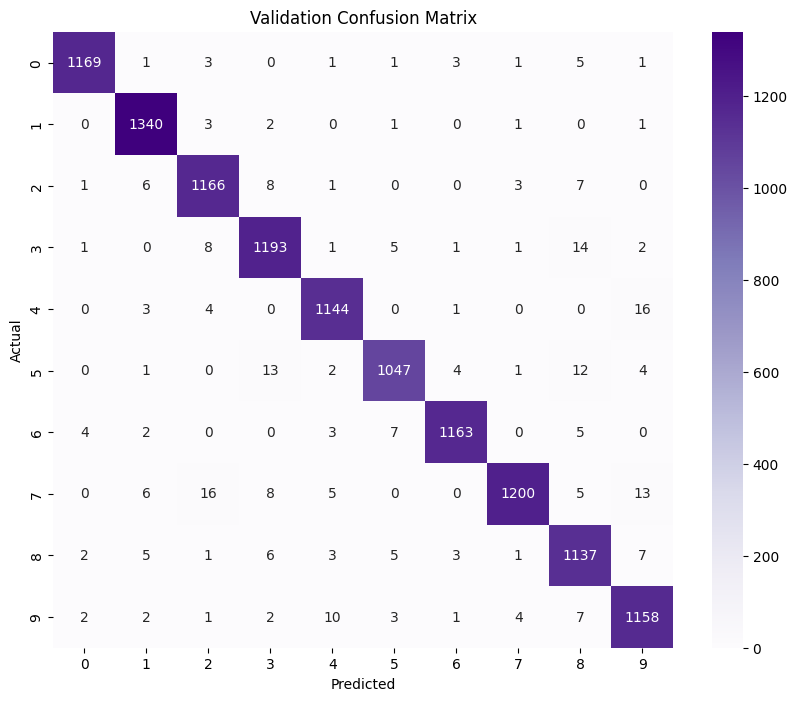

In [13]:
cm = confusion_matrix(y_val, pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
print(classification_report(y_val, pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1185
           1       0.98      0.99      0.99      1348
           2       0.97      0.98      0.97      1192
           3       0.97      0.97      0.97      1226
           4       0.98      0.98      0.98      1168
           5       0.98      0.97      0.97      1084
           6       0.99      0.98      0.99      1184
           7       0.99      0.96      0.97      1253
           8       0.95      0.97      0.96      1170
           9       0.96      0.97      0.97      1190

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



## Result Analysis

- High training accuracy + low validation accuracy = overfitting
- Similar train and validation scores = good generalization
- Lower loss is better
- Test accuracy confirms final real-world performance